Personalized Fitness Recommendation System Based on Human Activity Recognition and Daily Health Metrics

In [6]:
import pandas as pd
df = pd.read_csv('train.csv')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 564 entries, tBodyAccmeanX to ActivityName
dtypes: float64(561), int64(2), object(1)
memory usage: 31.6+ MB


,tBodyAccmeanX,tBodyAccmeanY,tBodyAccmeanZ,tBodyAccstdX,tBodyAccstdY,tBodyAccstdZ,tBodyAccmadX,tBodyAccmadY,tBodyAccmadZ,tBodyAccmaxX,...,angletBodyAccMeangravity,angletBodyAccJerkMeangravityMean,angletBodyGyroMeangravityMean,angletBodyGyroJerkMeangravityMean,angleXgravityMean,angleYgravityMean,angleZgravityMean,subject,Activity,ActivityName
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,5,STANDING


In [7]:
df.shape

(7352, 564)

In [8]:
df.columns

Index(['tBodyAccmeanX', 'tBodyAccmeanY', 'tBodyAccmeanZ', 'tBodyAccstdX',
       'tBodyAccstdY', 'tBodyAccstdZ', 'tBodyAccmadX', 'tBodyAccmadY',
       'tBodyAccmadZ', 'tBodyAccmaxX',
       ...
       'angletBodyAccMeangravity', 'angletBodyAccJerkMeangravityMean',
       'angletBodyGyroMeangravityMean', 'angletBodyGyroJerkMeangravityMean',
       'angleXgravityMean', 'angleYgravityMean', 'angleZgravityMean',
       'subject', 'Activity', 'ActivityName'],
      dtype='object', length=564)

In [9]:
df.isnull().sum()

,0
tBodyAccmeanX,0
tBodyAccmeanY,0
tBodyAccmeanZ,0
tBodyAccstdX,0
tBodyAccstdY,0
...,...
angleYgravityMean,0
angleZgravityMean,0
subject,0
Activity,0


In [10]:
df.describe()

,tBodyAccmeanX,tBodyAccmeanY,tBodyAccmeanZ,tBodyAccstdX,tBodyAccstdY,tBodyAccstdZ,tBodyAccmadX,tBodyAccmadY,tBodyAccmadZ,tBodyAccmaxX,...,fBodyBodyGyroJerkMagkurtosis,angletBodyAccMeangravity,angletBodyAccJerkMeangravityMean,angletBodyGyroMeangravityMean,angletBodyGyroJerkMeangravityMean,angleXgravityMean,angleYgravityMean,angleZgravityMean,subject,Activity
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085,3.643362
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143,1.744802
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000,2.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000,4.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000,5.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000,6.000000


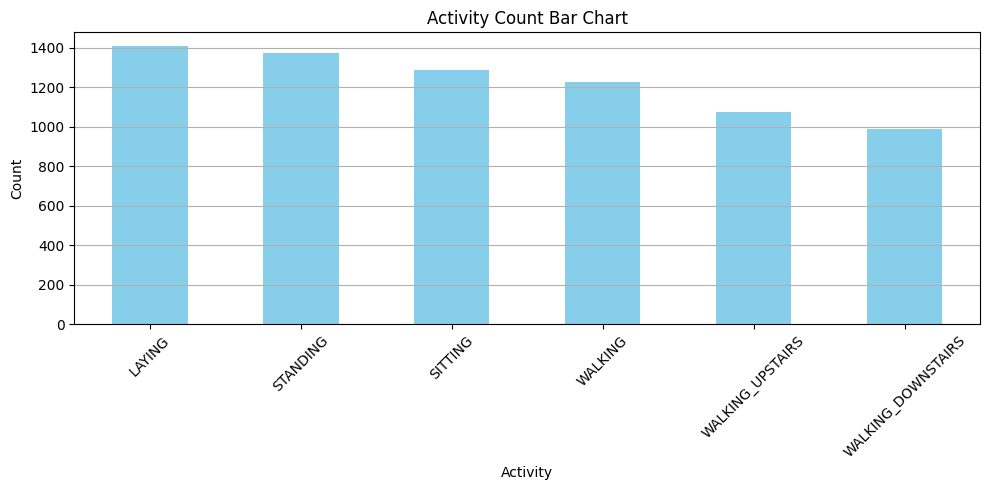

In [11]:
activity_counts = df["ActivityName"].value_counts()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
activity_counts.plot(kind="bar", color="skyblue")
plt.title("Activity Count Bar Chart")
plt.xlabel("Activity")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

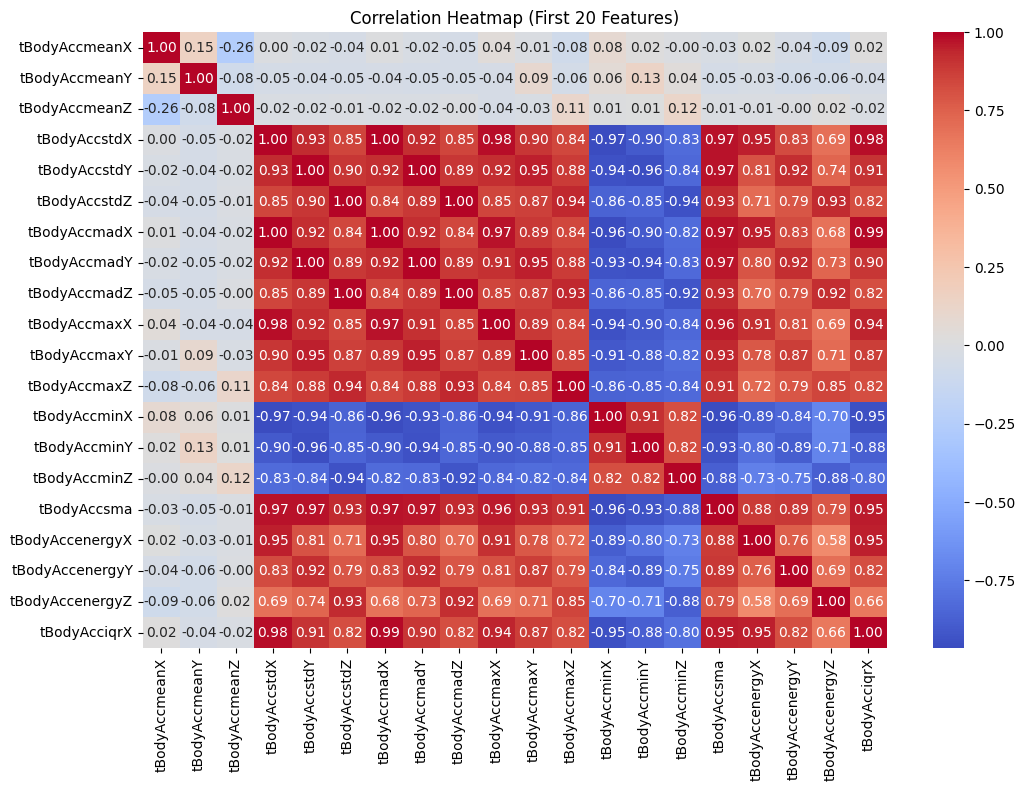

In [12]:
import seaborn as sns
X = df.drop(columns=['subject', 'Activity', 'ActivityName'])
plt.figure(figsize=(12, 8))
corr = X.iloc[:, :20].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (First 20 Features)")
plt.show()


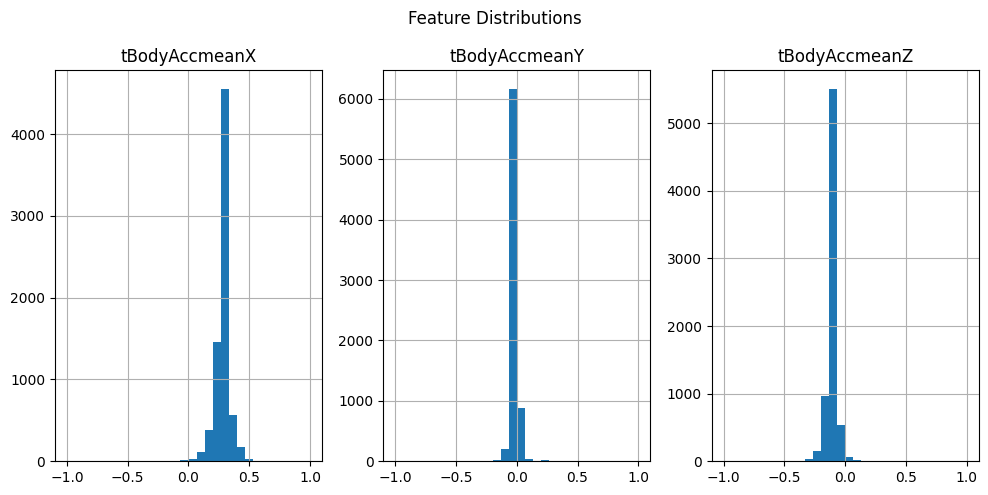

In [13]:
selected_features = ["tBodyAccmeanX", "tBodyAccmeanY", "tBodyAccmeanZ"]
df[selected_features].hist(bins=30, figsize=(10, 5), layout=(1, 3))
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

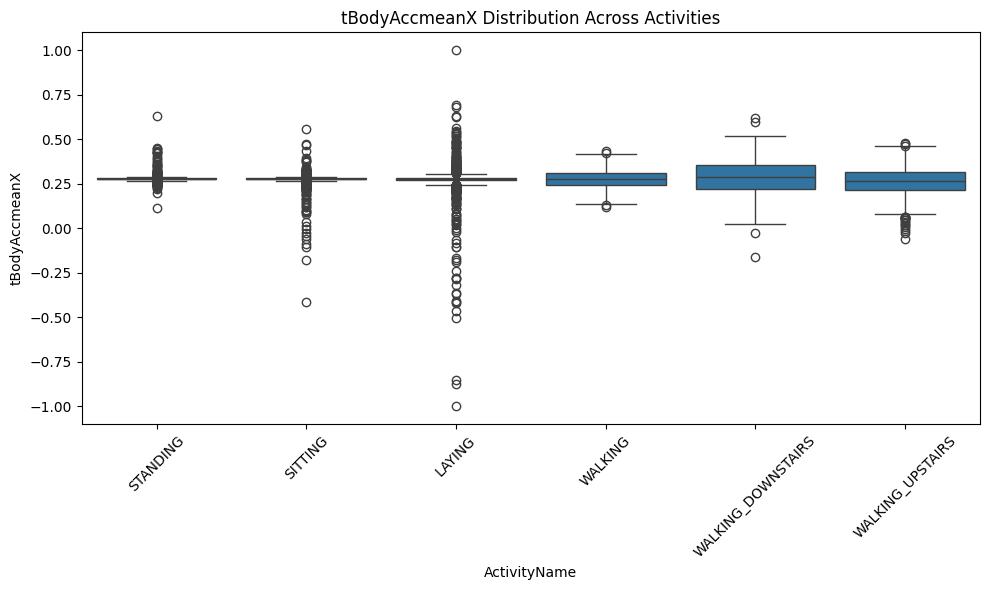

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="ActivityName", y="tBodyAccmeanX")
plt.xticks(rotation=45)
plt.title("tBodyAccmeanX Distribution Across Activities")
plt.tight_layout()
plt.show()


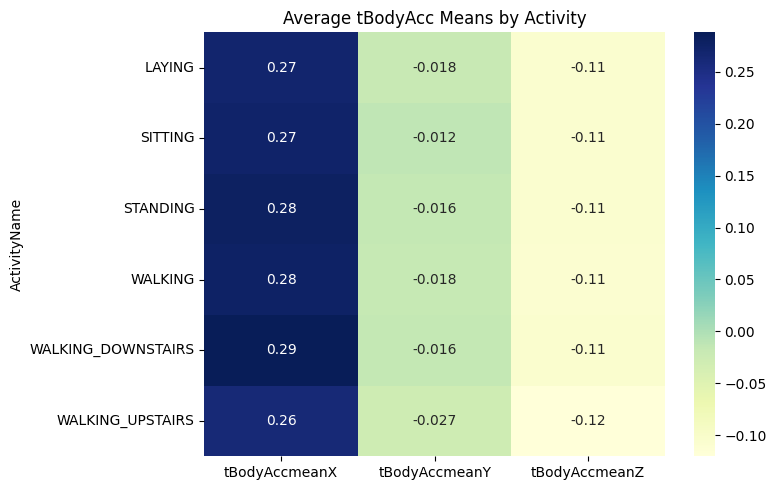

In [15]:
activity_means = df.groupby("ActivityName")[["tBodyAccmeanX", "tBodyAccmeanY", "tBodyAccmeanZ"]].mean()
plt.figure(figsize=(8, 5))
sns.heatmap(activity_means, annot=True, cmap="YlGnBu")
plt.title("Average tBodyAcc Means by Activity")
plt.tight_layout()
plt.show()

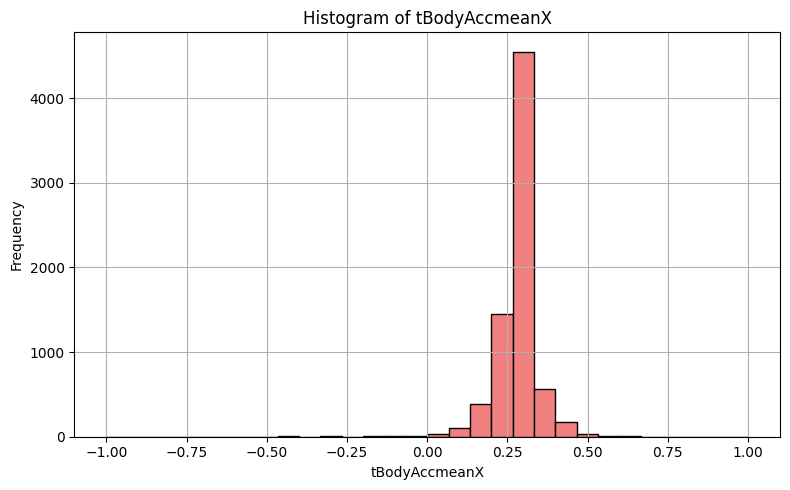

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(df["tBodyAccmeanX"], bins=30, color="lightcoral", edgecolor="black")
plt.title("Histogram of tBodyAccmeanX")
plt.xlabel("tBodyAccmeanX")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


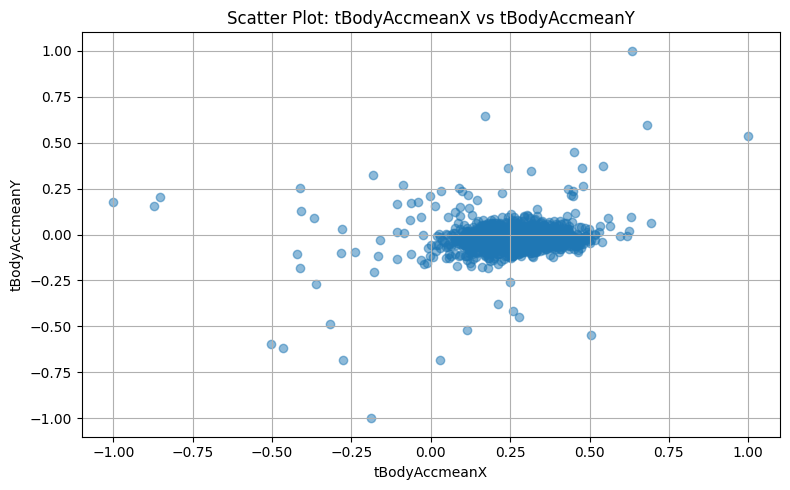

In [17]:
plt.figure(figsize=(8, 5))
plt.scatter(df["tBodyAccmeanX"], df["tBodyAccmeanY"], alpha=0.5)
plt.title("Scatter Plot: tBodyAccmeanX vs tBodyAccmeanY")
plt.xlabel("tBodyAccmeanX")
plt.ylabel("tBodyAccmeanY")
plt.grid(True)
plt.tight_layout()
plt.show()

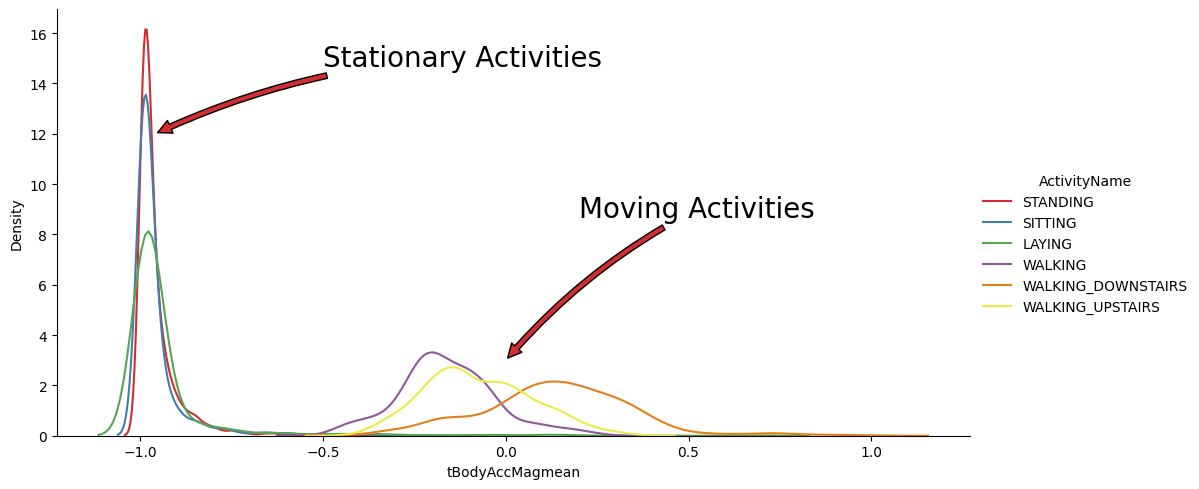

In [18]:
sns.set_palette("Set1", desat=0.80)
facetgrid = sns.FacetGrid(df, hue='ActivityName', height=5, aspect=2)
facetgrid.map(sns.kdeplot, 'tBodyAccMagmean').add_legend()
plt.annotate("Stationary Activities", xy=(-0.960, 12), xytext=(-0.5, 15), size=20,
             va='center', ha='left',
             arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=0.1"))

plt.annotate("Moving Activities", xy=(0, 3), xytext=(0.2, 9), size=20,
             va='center', ha='left',
             arrowprops=dict(arrowstyle="simple", connectionstyle="arc3,rad=0.1"))
plt.show()

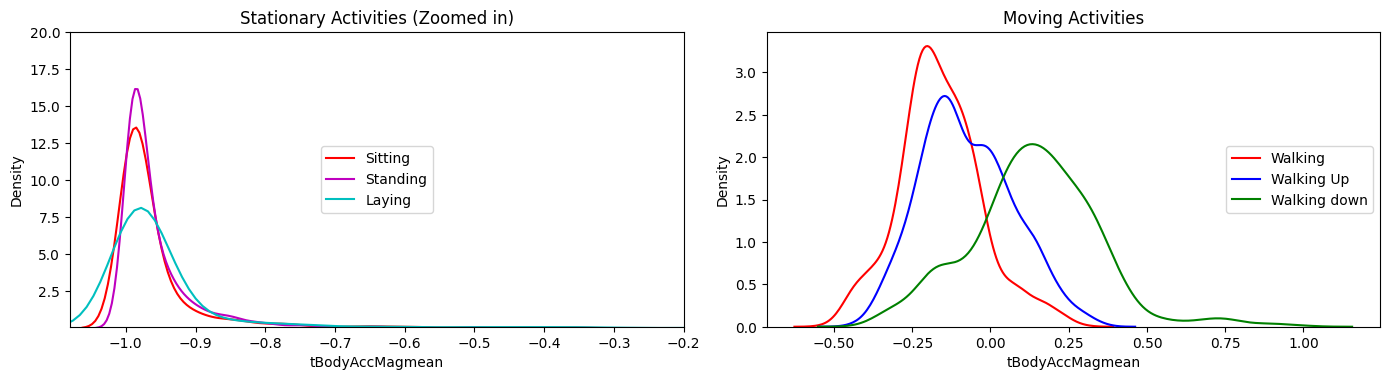

In [19]:
# for plotting purposes taking datapoints of each activity to a different dataframe
df1 = df[df['Activity'] == 1]
df2 = df[df['Activity'] == 2]
df3 = df[df['Activity'] == 3]
df4 = df[df['Activity'] == 4]
df5 = df[df['Activity'] == 5]
df6 = df[df['Activity'] == 6]

plt.figure(figsize=(14,7))

# Stationary Activities (Zoomed in)
plt.subplot(2,2,1)
plt.title('Stationary Activities (Zoomed in)')
sns.kdeplot(df4['tBodyAccMagmean'], color='r', label='Sitting')
sns.kdeplot(df5['tBodyAccMagmean'], color='m', label='Standing')
sns.kdeplot(df6['tBodyAccMagmean'], color='c', label='Laying')
plt.axis([-1.08, -0.2, 0.1, 20])
plt.legend(loc='center')

# Moving Activities
plt.subplot(2,2,2)
plt.title('Moving Activities')
sns.kdeplot(df1['tBodyAccMagmean'], color='red', label='Walking')
sns.kdeplot(df2['tBodyAccMagmean'], color='blue', label='Walking Up')
sns.kdeplot(df3['tBodyAccMagmean'], color='green', label='Walking down')
plt.legend(loc='center right')

plt.tight_layout()
plt.show()

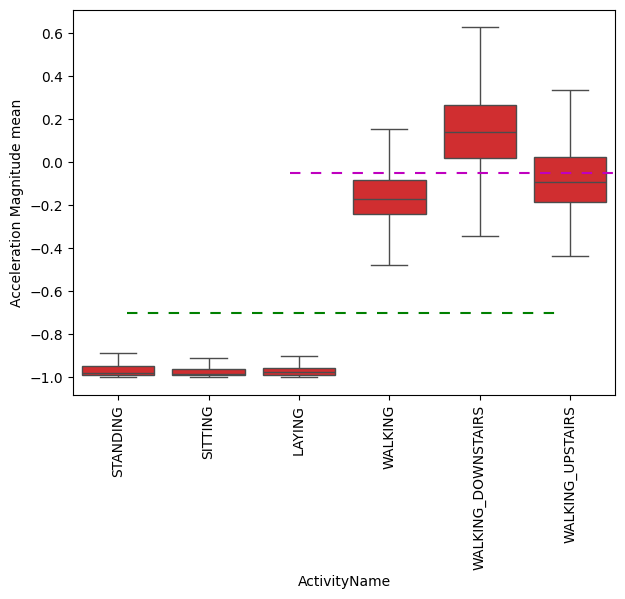

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='ActivityName', y='tBodyAccMagmean', data=df, showfliers=False, saturation=1)
plt.ylabel('Acceleration Magnitude mean')
plt.axhline(y=-0.7, xmin=0.1, xmax=0.9, dashes=(5,5), c='g')
plt.axhline(y=-0.05, xmin=0.4, dashes=(5,5), c='m')
plt.xticks(rotation=90)
plt.show()

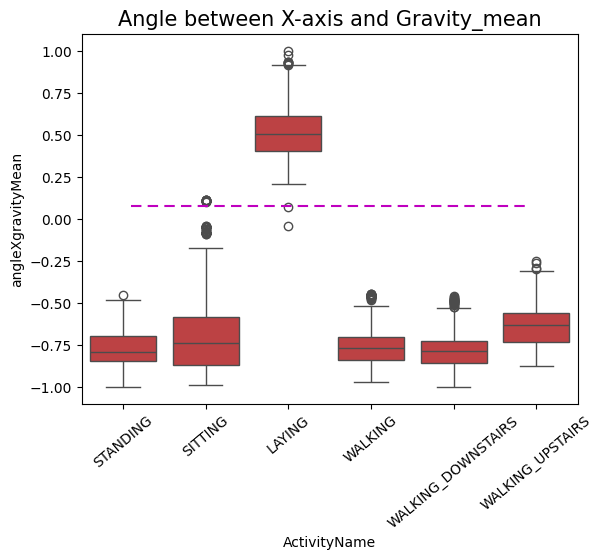

In [21]:
sns.boxplot(x='ActivityName', y='angleXgravityMean', data=df)
plt.axhline(y=0.08, xmin=0.1, xmax=0.9, c='m', dashes=(5,3))
plt.title('Angle between X-axis and Gravity_mean', fontsize=15)
plt.xticks(rotation=40)
plt.show()

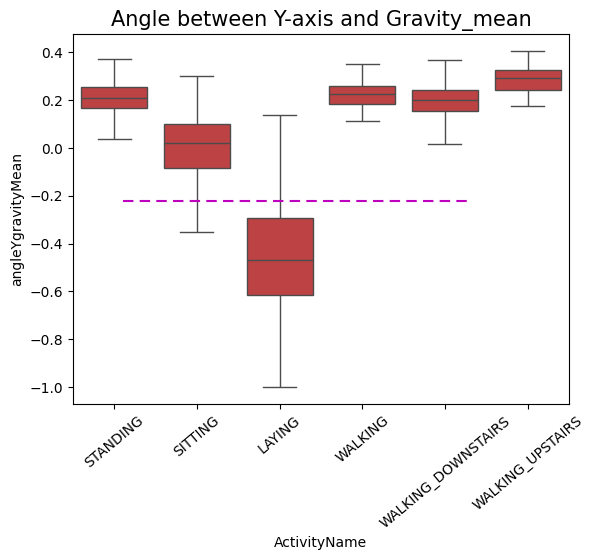

In [22]:
sns.boxplot(x='ActivityName', y='angleYgravityMean', data=df, showfliers=False)
plt.title('Angle between Y-axis and Gravity_mean', fontsize=15)
plt.xticks(rotation=40)
plt.axhline(y=-0.22, xmin=0.1, xmax=0.8, dashes=(5,3), c='m')
plt.show()

In [24]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# performs t-sne with different perplexity values and their repective plots..

def perform_tsne(X_data, y_data, perplexities, n_iter=1000, img_name_prefix='t-sne'):

    for index,perplexity in enumerate(perplexities):
        # perform t-sne
        print('\nperforming tsne with perplexity {} and with {} iterations at max'.format(perplexity, n_iter))
        X_reduced = TSNE(verbose=2, perplexity=perplexity).fit_transform(X_data)
        print('Done..')

        # prepare the data for seaborn
        print('Creating plot for this t-sne visualization..')
        df = pd.DataFrame({'x':X_reduced[:,0], 'y':X_reduced[:,1] ,'label':y_data})

        # draw the plot in appropriate place in the grid
        sns.lmplot(data=df, x='x', y='y', hue='label', fit_reg=False, height=8,\
                   palette="Set1",markers=['^','v','s','o', '1','2'])
        plt.title("perplexity : {} and max_iter : {}".format(perplexity, n_iter))
        img_name = img_name_prefix + '_perp_{}_iter_{}.png'.format(perplexity, n_iter)
        print('saving this plot as image in present working directory...')
        plt.savefig(img_name)
        plt.show()
        print('Done')


performing tsne with perplexity 2 and with 1000 iterations at max
[t-SNE] Computing 7 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.026s...
[t-SNE] Computed neighbors for 7352 samples in 4.062s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 0.597443
[t-SNE] Computed conditional probabilities in 0.037s
[t-SNE] Iteration 50: error = 119.3341904, gradient norm = 0.0451960 (50 iterations in 7.857s)
[t-SNE] Iteration 100: error = 105.1612167, gradient norm = 0.0241320 (50 iterations in 

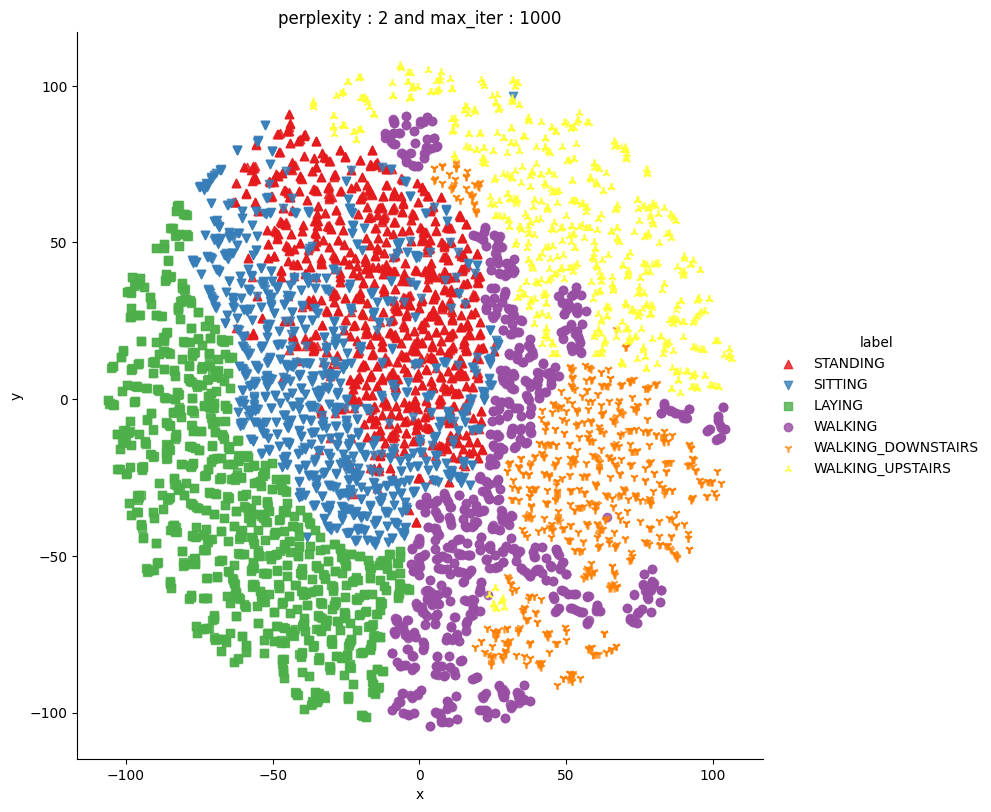

Done

performing tsne with perplexity 5 and with 1000 iterations at max
[t-SNE] Computing 16 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.028s...
[t-SNE] Computed neighbors for 7352 samples in 3.504s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 0.961446
[t-SNE] Computed conditional probabilities in 0.032s
[t-SNE] Iteration 50: error = 107.1774292, gradient norm = 0.0400609 (50 iterations in 5.812s)
[t-SNE] Iteration 100: error = 95.6881409, gradient norm = 0.0145624 (50 iteration

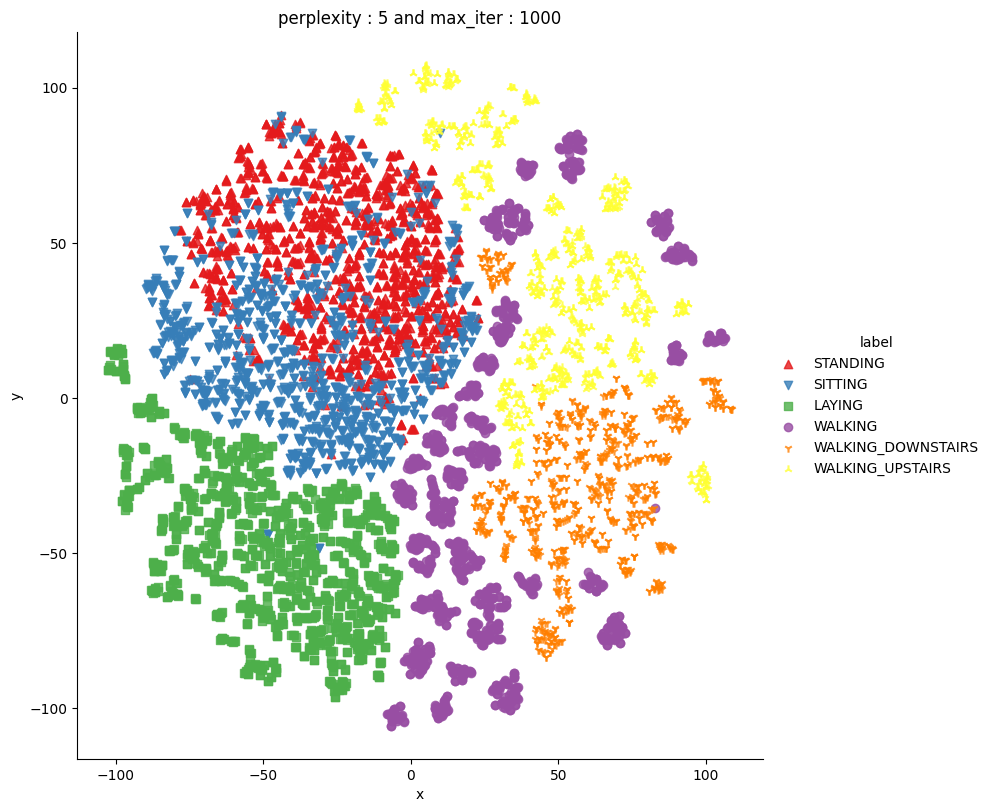

Done

performing tsne with perplexity 10 and with 1000 iterations at max
[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.025s...
[t-SNE] Computed neighbors for 7352 samples in 2.387s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.133827
[t-SNE] Computed conditional probabilities in 0.062s
[t-SNE] Iteration 50: error = 97.9004211, gradient norm = 0.0347215 (50 iterations in 7.369s)
[t-SNE] Iteration 100: error = 88.9403000, gradient norm = 0.0109358 (50 iteration

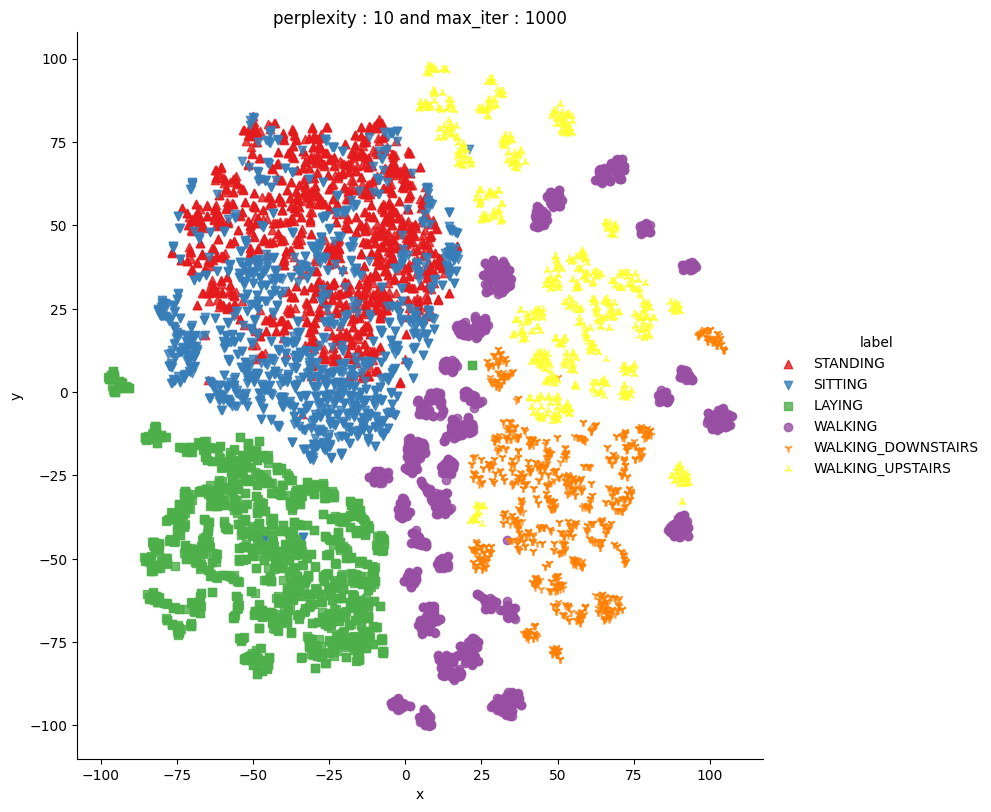

Done

performing tsne with perplexity 20 and with 1000 iterations at max
[t-SNE] Computing 61 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.023s...
[t-SNE] Computed neighbors for 7352 samples in 2.475s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.274336
[t-SNE] Computed conditional probabilities in 0.120s
[t-SNE] Iteration 50: error = 89.2854004, gradient norm = 0.0326881 (50 iterations in 8.155s)
[t-SNE] Iteration 100: error = 82.9631805, gradient norm = 0.0080145 (50 iteration

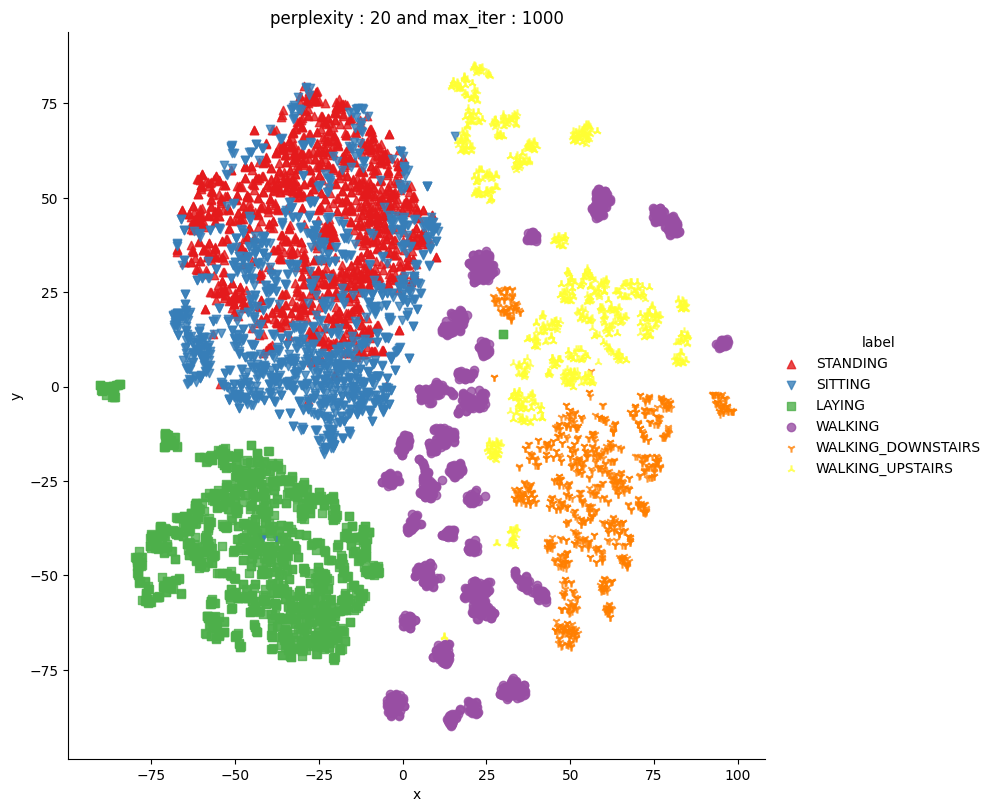

Done

performing tsne with perplexity 50 and with 1000 iterations at max
[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 7352 samples in 0.025s...
[t-SNE] Computed neighbors for 7352 samples in 3.936s...
[t-SNE] Computed conditional probabilities for sample 1000 / 7352
[t-SNE] Computed conditional probabilities for sample 2000 / 7352
[t-SNE] Computed conditional probabilities for sample 3000 / 7352
[t-SNE] Computed conditional probabilities for sample 4000 / 7352
[t-SNE] Computed conditional probabilities for sample 5000 / 7352
[t-SNE] Computed conditional probabilities for sample 6000 / 7352
[t-SNE] Computed conditional probabilities for sample 7000 / 7352
[t-SNE] Computed conditional probabilities for sample 7352 / 7352
[t-SNE] Mean sigma: 1.437672
[t-SNE] Computed conditional probabilities in 0.324s
[t-SNE] Iteration 50: error = 78.8192520, gradient norm = 0.0249539 (50 iterations in 11.813s)
[t-SNE] Iteration 100: error = 75.2192612, gradient norm = 0.0056113 (50 iterati

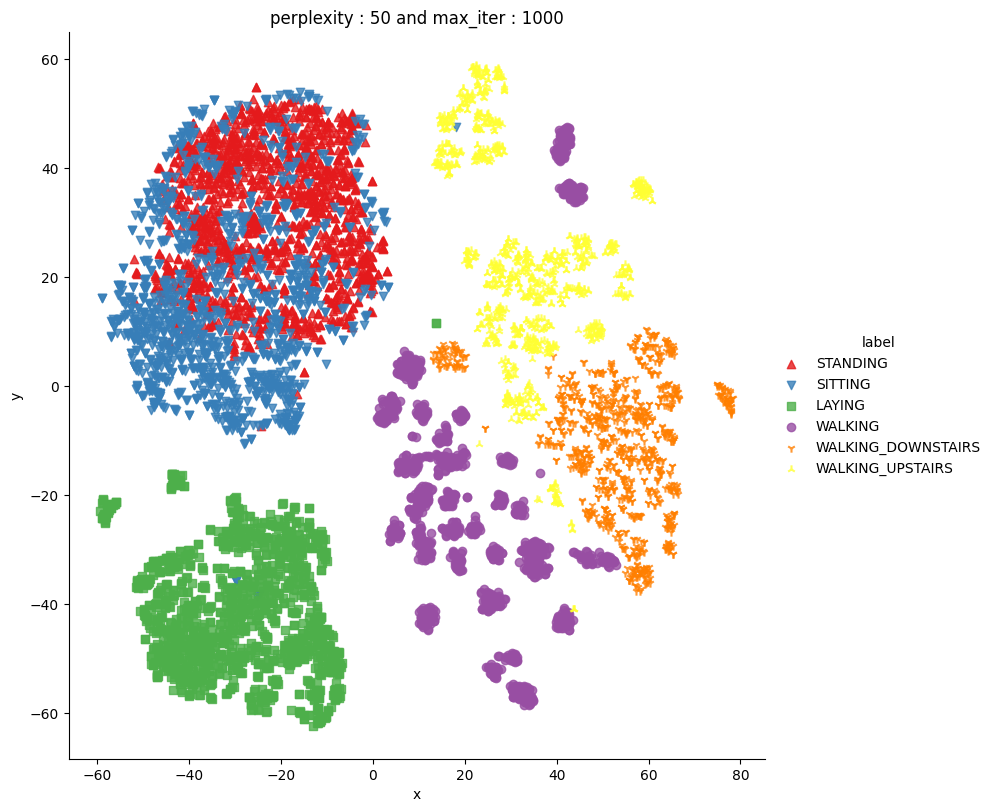

Done


In [26]:
X_pre_tsne = df.drop(['subject', 'Activity', 'ActivityName'], axis=1)
y_pre_tsne = df['ActivityName']
perform_tsne(X_data=X_pre_tsne, y_data=y_pre_tsne, perplexities=[2, 5, 10, 20, 50])

DATA CLEANING

In [27]:
import pandas as pd

df = pd.read_csv("train.csv")

print("Missing values per column:\n", df.isnull().sum())

print("Number of duplicate rows:", df.duplicated().sum())

df_cleaned = df.drop_duplicates()

df_cleaned = df_cleaned.dropna()

df_cleaned.to_csv("train_cleaned.csv", index=False)

print("Cleaned data shape:", df_cleaned.shape)

print("Cleaned data saved to 'train_cleaned.csv'")

Missing values per column:
 tBodyAccmeanX        0
tBodyAccmeanY        0
tBodyAccmeanZ        0
tBodyAccstdX         0
tBodyAccstdY         0
                    ..
angleYgravityMean    0
angleZgravityMean    0
subject              0
Activity             0
ActivityName         0
Length: 564, dtype: int64
Number of duplicate rows: 0
Cleaned data shape: (7352, 564)
Cleaned data saved to 'train_cleaned.csv'


DATA PREPROCESSING

In [28]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = df_cleaned.drop(columns=['Activity', 'ActivityName', 'subject'])
y = df_cleaned['ActivityName']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)

In [35]:
import pandas as pd
df = pd.read_csv('train.csv')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Feature and label split
X = df.drop(columns=['subject', 'Activity', 'ActivityName'])
y = df['ActivityName']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



RANDOM FOREST MODEL

Random Forest Accuracy: 0.9823

Random Forest Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.98      0.95      0.96       257
          STANDING       0.95      0.98      0.97       275
           WALKING       0.99      0.99      0.99       245
WALKING_DOWNSTAIRS       0.97      0.98      0.98       197
  WALKING_UPSTAIRS       1.00      0.99      0.99       215

          accuracy                           0.98      1471
         macro avg       0.98      0.98      0.98      1471
      weighted avg       0.98      0.98      0.98      1471



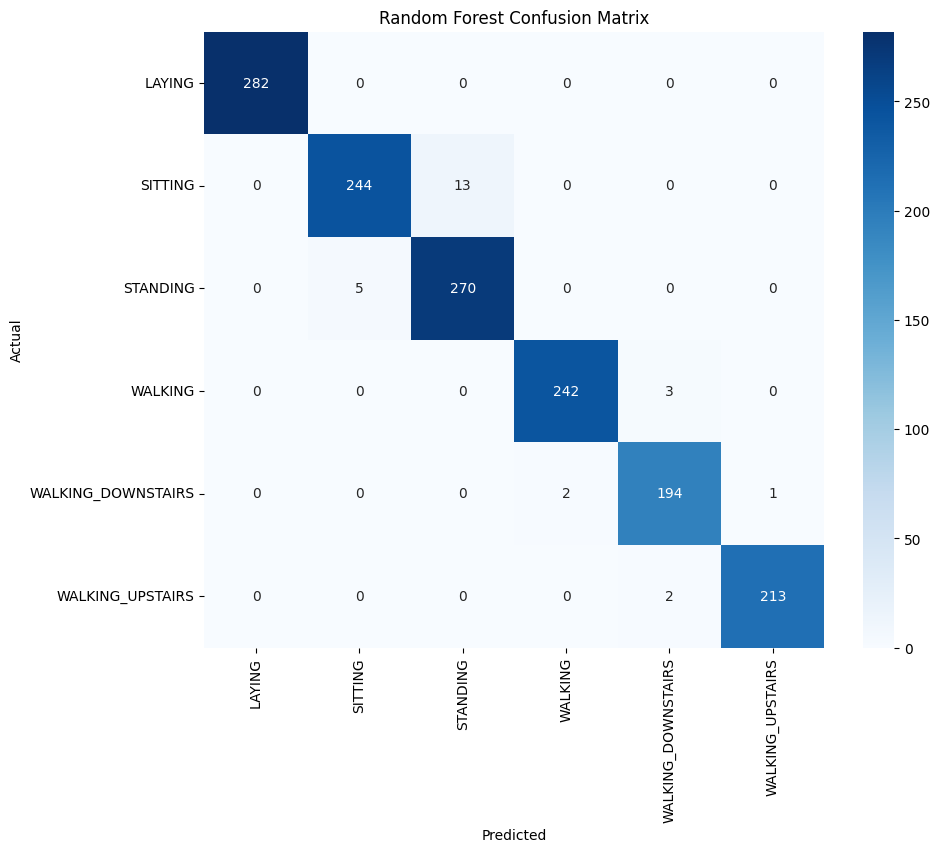

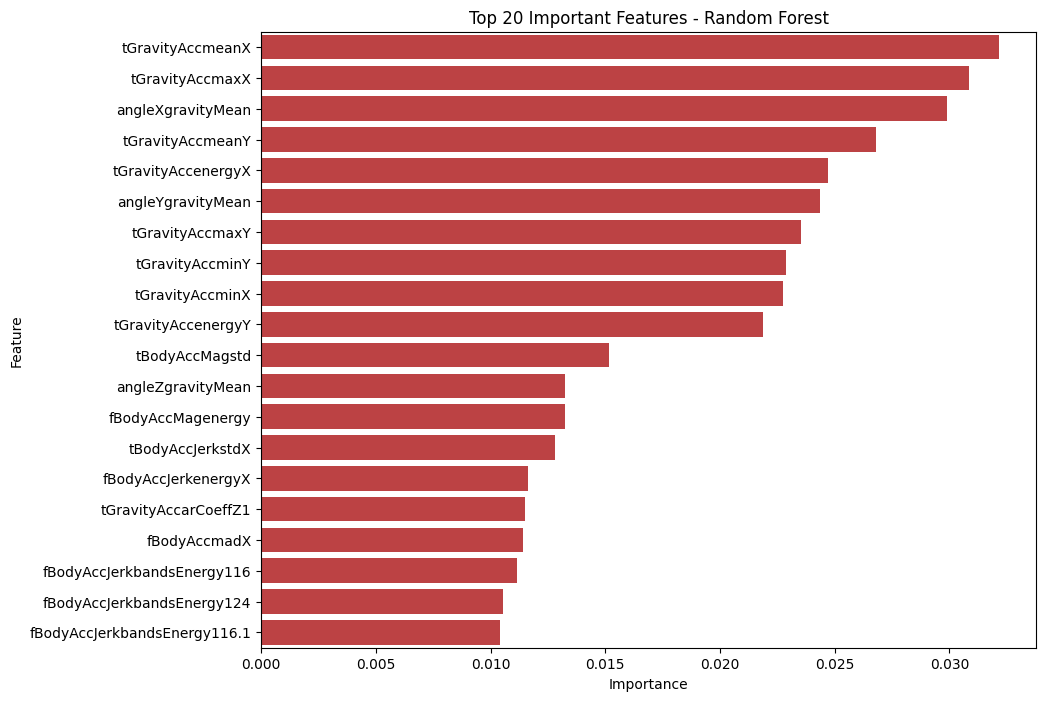

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Model Accuracy: 0.9796091758708582
Classification Report (Tuned Model):
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       225
           SITTING       0.98      0.94      0.96       206
          STANDING       0.95      0.98      0.96       220
           WALKING       1.00      0.99      0.99       196
WALKING_DOWNSTAIRS       0.97      0.98      0.98       158
  WALKING_UPSTAIRS       0.98      0.98      0.98       172

          accuracy                           0.98      1177
         macro avg       0.98      0.98      0.98      1177
      weighted avg       0.98      0.98      0.98      1177


STANDALONE LSTM MODEL


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 64)             │       160,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,534 (634.90 KB)

 Trainable params: 162,534 (634.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7687 - loss: 0.7484 - val_accuracy: 0.9116 - val_loss: 0.3057
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9358 - loss: 0.2251 - val_accuracy: 0.9558 - val_loss: 0.1374
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9622 - loss: 0.1249 - val_accuracy: 0.9609 - val_loss: 0.1063
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9732 - loss: 0.0923 - val_accuracy: 0.9728 - val_loss: 0.0799
Epoch 5/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9700 - loss: 0.0840 - val_accuracy: 0.9737 - val_loss: 0.0780
Epoch 6/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9760 - loss: 0.0695 - val_accuracy: 0.9720 - val_loss: 0.0743
Epoch 7/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9832 - loss: 0.0533 - val_accuracy: 0.9762 - val_loss: 0.0625
Epoch 8/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9809 - loss: 0.0514 - val_accuracy: 0.9737 - val_loss

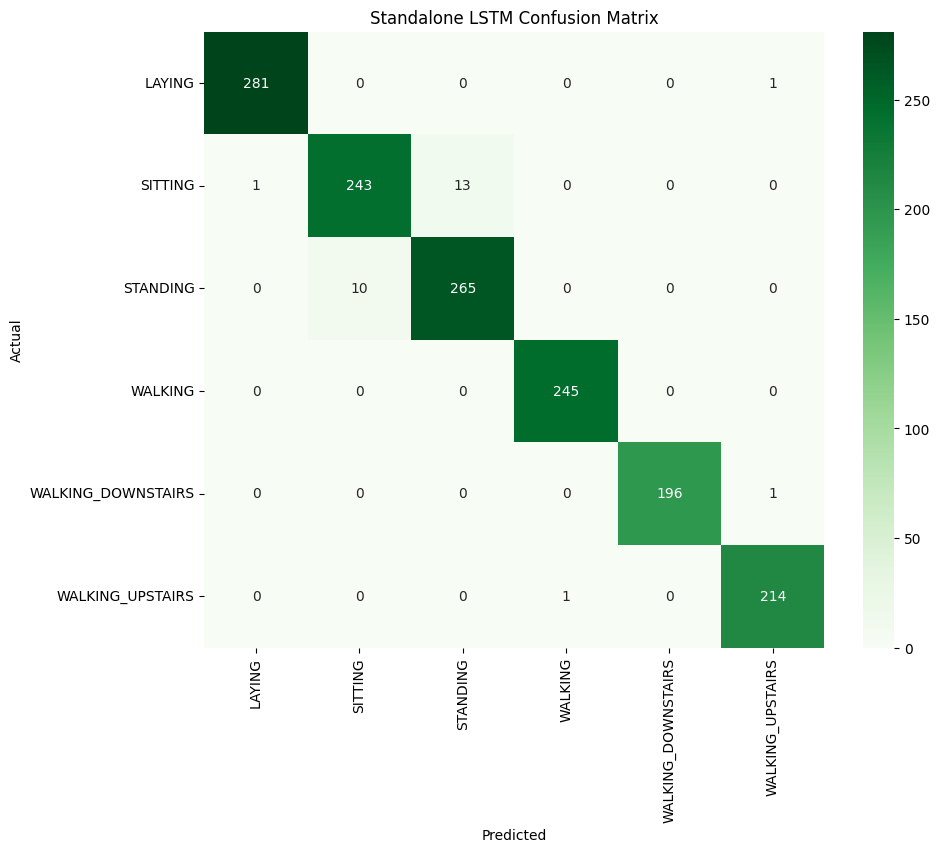


HYBRID RF + LSTM MODEL


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ lstm_input          │ (None, 1, 561)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 64)        │    160,256 │ lstm_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      2,080 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rf_input            │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 38)        │          0 │ dense_9[0][0],    │
│ (Concatenate)       │                   │            │ rf_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      2,496 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 6)         │        390 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 165,222 (645.40 KB)

 Trainable params: 165,222 (645.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7651 - loss: 0.7602 - val_accuracy: 0.9541 - val_loss: 0.2083
Epoch 2/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9522 - loss: 0.1841 - val_accuracy: 0.9830 - val_loss: 0.0888
Epoch 3/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9809 - loss: 0.0851 - val_accuracy: 0.9873 - val_loss: 0.0479
Epoch 4/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9887 - loss: 0.0494 - val_accuracy: 0.9915 - val_loss: 0.0413
Epoch 5/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9909 - loss: 0.0385 - val_accuracy: 0.9924 - val_loss: 0.0286
Epoch 6/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9926 - loss: 0.0296 - val_accuracy: 0.9949 - val_loss: 0.0226
Epoch 7/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9962 - loss: 0.0179 - val_accuracy: 0.9958 - val_loss: 0.0175
Epoch 8/25
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9957 - loss: 0.0177 - val_accuracy: 0.9966 - val_l

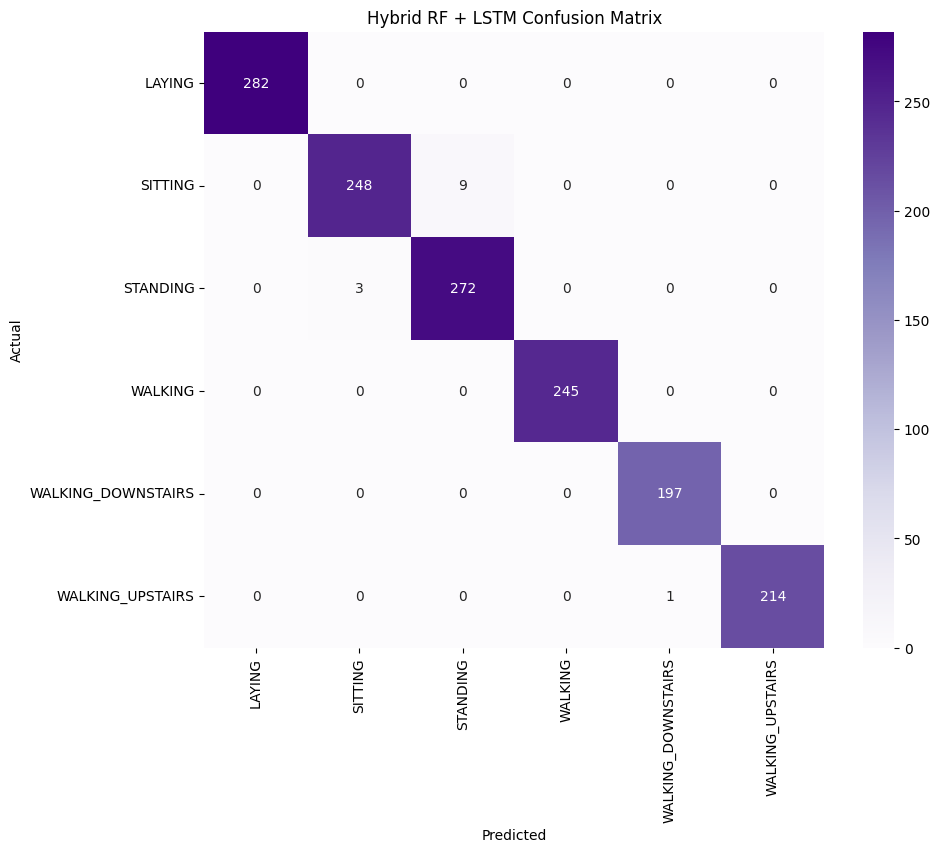

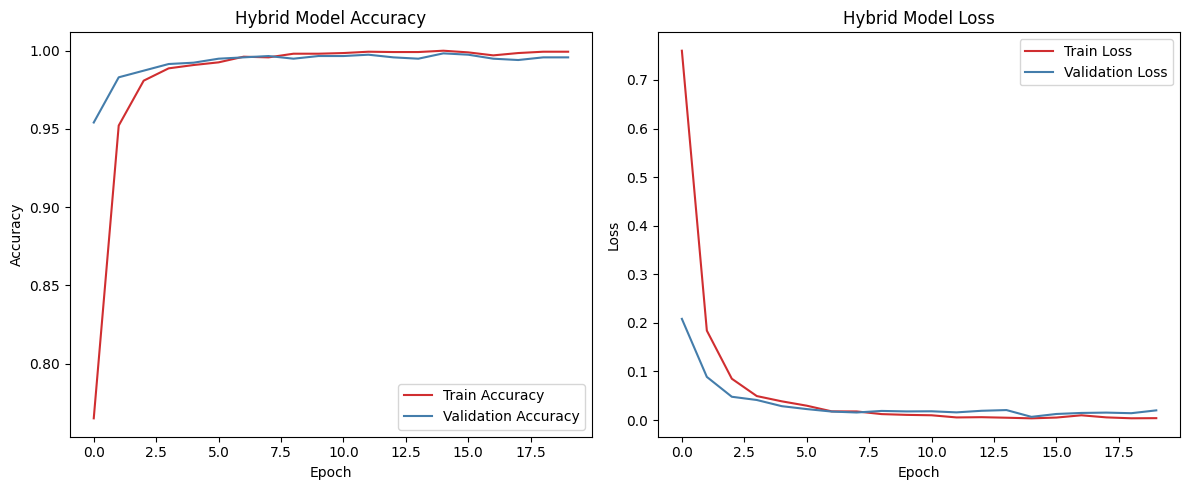


All Models Saved Successfully!


In [34]:
# ============================================================
# HYBRID RANDOM FOREST + LSTM MODEL FOR HAR
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, LSTM, Concatenate
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("train_cleaned.csv")

# ============================================================
# FEATURE & LABEL SPLIT
# ============================================================

X = df.drop(columns=["Activity", "ActivityName", "subject"])
y = df["ActivityName"]

# ============================================================
# LABEL ENCODING
# ============================================================

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

# ============================================================
# ONE HOT ENCODING
# ============================================================

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# ============================================================
# RANDOM FOREST MODEL
# ============================================================

print("\n==============================")
print("RANDOM FOREST MODEL")
print("==============================")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_leaf=2,
    max_features='sqrt'
)

rf.fit(X_train, y_train)

# ============================================================
# RANDOM FOREST PREDICTIONS
# ============================================================

y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")

print("\nRandom Forest Classification Report:")

print(classification_report(
    y_test,
    y_pred_rf,
    target_names=le.classes_
))

# ============================================================
# RANDOM FOREST CONFUSION MATRIX
# ============================================================

conf_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10,8))

sns.heatmap(
    conf_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(20)
)

plt.title("Top 20 Important Features - Random Forest")

plt.show()

# ============================================================
# RANDOM FOREST PROBABILITIES
# ============================================================

rf_train_proba = rf.predict_proba(X_train)
rf_test_proba = rf.predict_proba(X_test)

# ============================================================
# RESHAPE DATA FOR LSTM
# ============================================================

X_train_lstm = X_train.reshape(
    (X_train.shape[0], 1, X_train.shape[1])
)

X_test_lstm = X_test.reshape(
    (X_test.shape[0], 1, X_test.shape[1])
)
from sklearn.model_selection import GridSearchCV, train_test_split

# Splitting training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Grid search with cross-validation
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_split, y_train_split)

# Best model
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Evaluation on validation set
y_pred_best = best_model.predict(X_val_split)
print("Tuned Model Accuracy:", accuracy_score(y_val_split, y_pred_best))
print("Classification Report (Tuned Model):")
print(classification_report(y_val_split, y_pred_best, target_names=le.classes_))


# ============================================================
# STANDALONE LSTM MODEL
# ============================================================

print("\n==============================")
print("STANDALONE LSTM MODEL")
print("==============================")

model_lstm = Sequential()

model_lstm.add(
    LSTM(
        64,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    )
)

model_lstm.add(Dropout(0.3))

model_lstm.add(Dense(32, activation='relu'))

model_lstm.add(
    Dense(
        y_train_cat.shape[1],
        activation='softmax'
    )
)

# ============================================================
# COMPILE LSTM MODEL
# ============================================================

model_lstm.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()

# ============================================================
# TRAIN LSTM MODEL
# ============================================================

history_lstm = model_lstm.fit(
    X_train_lstm,
    y_train_cat,
    validation_split=0.2,
    epochs=25,
    batch_size=64,
    verbose=1
)

# ============================================================
# EVALUATE LSTM MODEL
# ============================================================

loss_lstm, accuracy_lstm = model_lstm.evaluate(
    X_test_lstm,
    y_test_cat,
    verbose=0
)

print(f"\nStandalone LSTM Accuracy: {accuracy_lstm:.4f}")

# ============================================================
# LSTM PREDICTIONS
# ============================================================

y_pred_lstm_probs = model_lstm.predict(X_test_lstm)

y_pred_lstm = np.argmax(y_pred_lstm_probs, axis=1)

# ============================================================
# LSTM CLASSIFICATION REPORT
# ============================================================

print("\nStandalone LSTM Classification Report:")

print(classification_report(
    y_test,
    y_pred_lstm,
    target_names=le.classes_
))

# ============================================================
# LSTM CONFUSION MATRIX
# ============================================================

conf_lstm = confusion_matrix(
    y_test,
    y_pred_lstm
)

plt.figure(figsize=(10,8))

sns.heatmap(
    conf_lstm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Standalone LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# HYBRID RF + LSTM MODEL
# ============================================================

print("\n==============================")
print("HYBRID RF + LSTM MODEL")
print("==============================")

# ============================================================
# LSTM INPUT
# ============================================================

lstm_input = Input(
    shape=(
        X_train_lstm.shape[1],
        X_train_lstm.shape[2]
    ),
    name="lstm_input"
)

# ============================================================
# LSTM LAYERS
# ============================================================

x = LSTM(64, return_sequences=False)(lstm_input)

x = Dropout(0.3)(x)

x = Dense(32, activation='relu')(x)

# ============================================================
# RANDOM FOREST INPUT
# ============================================================

rf_input = Input(
    shape=(rf_train_proba.shape[1],),
    name="rf_input"
)

# ============================================================
# COMBINE RF + LSTM
# ============================================================

combined = Concatenate()([x, rf_input])

# ============================================================
# FINAL DENSE LAYERS
# ============================================================

z = Dense(64, activation='relu')(combined)

z = Dropout(0.3)(z)

output = Dense(
    y_train_cat.shape[1],
    activation='softmax'
)(z)

# ============================================================
# FINAL HYBRID MODEL
# ============================================================

hybrid_model = Model(
    inputs=[lstm_input, rf_input],
    outputs=output
)

hybrid_model.summary()

# ============================================================
# COMPILE HYBRID MODEL
# ============================================================

hybrid_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ============================================================
# EARLY STOPPING
# ============================================================

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# ============================================================
# TRAIN HYBRID MODEL
# ============================================================

history_hybrid = hybrid_model.fit(
    [X_train_lstm, rf_train_proba],
    y_train_cat,
    validation_split=0.2,
    epochs=25,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# ============================================================
# EVALUATE HYBRID MODEL
# ============================================================

loss_hybrid, accuracy_hybrid = hybrid_model.evaluate(
    [X_test_lstm, rf_test_proba],
    y_test_cat,
    verbose=0
)

print(f"\nHybrid RF + LSTM Accuracy: {accuracy_hybrid:.4f}")

# ============================================================
# HYBRID PREDICTIONS
# ============================================================

y_pred_hybrid_probs = hybrid_model.predict(
    [X_test_lstm, rf_test_proba]
)

y_pred_hybrid = np.argmax(
    y_pred_hybrid_probs,
    axis=1
)

# ============================================================
# HYBRID CLASSIFICATION REPORT
# ============================================================

print("\nHybrid RF + LSTM Classification Report:")

print(classification_report(
    y_test,
    y_pred_hybrid,
    target_names=le.classes_
))

# ============================================================
# HYBRID CONFUSION MATRIX
# ============================================================

conf_hybrid = confusion_matrix(
    y_test,
    y_pred_hybrid
)

plt.figure(figsize=(10,8))

sns.heatmap(
    conf_hybrid,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Hybrid RF + LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# HYBRID ACCURACY & LOSS CURVES
# ============================================================

plt.figure(figsize=(12,5))

# Accuracy Curve
plt.subplot(1,2,1)

plt.plot(
    history_hybrid.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history_hybrid.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Hybrid Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

# Loss Curve
plt.subplot(1,2,2)

plt.plot(
    history_hybrid.history['loss'],
    label='Train Loss'
)

plt.plot(
    history_hybrid.history['val_loss'],
    label='Validation Loss'
)

plt.title('Hybrid Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# SAVE MODELS
# ============================================================

model_lstm.save("standalone_lstm_model.h5")

hybrid_model.save("hybrid_rf_lstm_model.h5")

joblib.dump(rf, "random_forest_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(le, "label_encoder.pkl")

print("\nAll Models Saved Successfully!")